# À l'origine : le sac de mots

## Données

Repartons des données que nous avons mis en forme, et amenons progressivement une analyse plus avancée

In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/pyshs/URFIST-Lyon-2026/refs/heads/main/data/css_openalex_26022026.csv")
df["title"] = df["title"].fillna("")
df["abstract"] = df["abstract"].fillna("")
df["texte"] = df["title"]+ df["abstract"]
df = df[(df["texte"].str.len() > 100) & (df["texte"].str.len() < 5000)]
df.head()

,id,type,primary_location,title,abstract_inverted_index,publication_year,publication_date,open_access,relevance_score,abstract,journal,texte
0,https://openalex.org/W2159397589,article,"{'id': 'doi:10.1126/science.1167742', 'is_oa':...",Computational Social Science,"{'A': [0], 'field': [1], 'is': [2], 'emerging'...",2009.0,2009-02-06,"{'is_oa': True, 'oa_status': 'green', 'oa_url'...",1360.35770,A field is emerging that leverages the capacit...,Science,Computational Social ScienceA field is emergin...
2,https://openalex.org/W3081158114,article,"{'id': 'doi:10.1126/science.aaz8170', 'is_oa':...",Computational social science: Obstacles and op...,"{'Data': [0], 'sharing,': [1], 'research': [2]...",2020.0,2020-08-28,"{'is_oa': True, 'oa_status': 'green', 'oa_url'...",438.53986,"Data sharing, research ethics, and incentives ...",Science,Computational social science: Obstacles and op...
3,https://openalex.org/W3022499311,article,{'id': 'doi:10.1146/annurev-soc-121919-054621'...,Computational Social Science and Sociology,"{'The': [0], 'integration': [1], 'of': [2, 16,...",2020.0,2020-04-28,"{'is_oa': True, 'oa_status': 'hybrid', 'oa_url...",413.03424,The integration of social science with compute...,Annual Review of Sociology,Computational Social Science and SociologyThe ...
5,https://openalex.org/W4389636360,article,"{'id': 'doi:10.1162/coli_a_00502', 'is_oa': Tr...",Can Large Language Models Transform Computatio...,"{'Abstract': [0], 'Large': [1], 'language': [2...",2023.0,2023-12-12,"{'is_oa': True, 'oa_status': 'diamond', 'oa_ur...",383.01935,Abstract Large language models (LLMs) are capa...,Computational Linguistics,Can Large Language Models Transform Computatio...
7,https://openalex.org/W2790659496,review,"{'id': 'doi:10.1002/wics.95', 'is_oa': False, ...",Computational social science,"{'Abstract': [0], 'The': [1, 52], 'social': [2...",2010.0,2010-05-01,"{'is_oa': False, 'oa_status': 'closed', 'oa_ur...",343.03370,Abstract The social sciences investigate human...,Wiley Interdisciplinary Reviews Computational ...,Computational social scienceAbstract The socia...


## Transformer le texte en nombres : le comptage de mots

### Découper en mots

In [2]:
#df["texte"].apply(lambda x: x.split(" ")).str.len()
df["texte"].apply(lambda x: x.split(" ")).head()

0    [Computational, Social, ScienceA, field, is, e...
2    [Computational, social, science:, Obstacles, a...
3    [Computational, Social, Science, and, Sociolog...
5    [Can, Large, Language, Models, Transform, Comp...
7    [Computational, social, scienceAbstract, The, ...
Name: texte, dtype: object

### Utiliser NLTK

In [3]:
import nltk
nltk.download('punkt')
print(nltk.__version__)
from nltk.tokenize import word_tokenize
texte = "Ceci est un test. Coucou, je fais du Python. N'est-ce-pas?"
word_tokenize(texte, language="french")

3.9.4


[nltk_data] Downloading package punkt to /Users/emilien/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['Ceci',
 'est',
 'un',
 'test',
 '.',
 'Coucou',
 ',',
 'je',
 'fais',
 'du',
 'Python',
 '.',
 "N'est-ce-pas",
 '?']

In [4]:
df["texte_en_mots"] = df["texte"].apply(word_tokenize)

Les limites de NLTK (notamment le français)

#### De nombreuses fonctions 

Compter les bigrams

In [5]:
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
text = "Ceci est un test. Coucou, je fais du Python. N'est-ce-pas?"
tokens = word_tokenize(text.lower())
bigrams = list(ngrams(tokens, 2))
bigrams

[('ceci', 'est'),
 ('est', 'un'),
 ('un', 'test'),
 ('test', '.'),
 ('.', 'coucou'),
 ('coucou', ','),
 (',', 'je'),
 ('je', 'fais'),
 ('fais', 'du'),
 ('du', 'python'),
 ('python', '.'),
 ('.', "n'est-ce-pas"),
 ("n'est-ce-pas", '?')]

### Préprocessing : nettoyer les données

- Beaucoup d'opérations de nettoyage, spécifiques à chaque tache

In [6]:
nltk.download("stopwords")
from nltk.corpus import stopwords

english_stopwords = list(set(stopwords.words("english")))


def generate_bigrams_nltk(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [token for token in tokens if token.isalnum() and token not in english_stopwords]
    bigrams = list(ngrams(filtered_tokens, 2))
    return bigrams

generate_bigrams_nltk(df.loc[0, "texte"])


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/emilien/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('computational', 'social'),
 ('social', 'sciencea'),
 ('sciencea', 'field'),
 ('field', 'emerging'),
 ('emerging', 'leverages'),
 ('leverages', 'capacity'),
 ('capacity', 'collect'),
 ('collect', 'analyze'),
 ('analyze', 'data'),
 ('data', 'scale'),
 ('scale', 'may'),
 ('may', 'reveal'),
 ('reveal', 'patterns'),
 ('patterns', 'individual'),
 ('individual', 'group'),
 ('group', 'behaviors')]

## DTM : document term matrix

Le faire à la main. Ou rapide avec Scikit-learn

In [7]:
#pip install scikit-learn

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

# créer mon object de ML
vectorizer = CountVectorizer(stop_words=english_stopwords + [str(i) for i in range(0, 10000)], 
                             ngram_range=(1, 1), 
                             max_features=800)

# appliquer sur les données
X = vectorizer.fit_transform(df["texte"])
X = pd.DataFrame(X.toarray(),columns=list(vectorizer.get_feature_names_out()))
X

,ability,academic,access,accounts,accuracy,across,action,actions,active,activities,...,words,work,working,works,workshop,world,www,years,yet,youtube
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1758,0,0,0,0,0,0,0,0,0,0,...,0,2,0,1,0,0,0,0,0,0
1759,0,0,0,0,0,3,0,0,0,0,...,0,5,0,0,0,0,0,0,0,0
1760,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,1,0,0,0
1761,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,1,0,0,0


In [9]:
df.iloc[1760]["texte"]

'Exploring ChatGPT’s capabilities, stability, potential and risks in conducting psychological counseling through simulations in school counselingCitation: Ni, Y. and Cao, Y. (2025), "Exploring ChatGPT’s capabilities, stability, potential and risks in conducting psychological counseling through simulations in school counseling", Mental Health and Digital Technologies, Vol. ahead-of-print No. ahead-of-print. https://doi.org/10.1108/MHDT-02-2025-0013Find published version at https://www.emerald.com/insight/content/doi/10.1108/MHDT-02-2025-0013/full/htmlPurposeThis study aims to examine ChatGPT-4’s potential and stability when simulating school-counseling dialogues, offering an exploratory snapshot of its ability to convey warmth, empathy and acceptance. Drawing on 80 real student questions, this paper aims to assess response consistency and identify risk markers, such as randomness and hallucination. The goal of this study is to inform future research, guide human–AI (artificial intellige

## Une version un peu plus avancée

- Term Frequency-Inverse Document Frequency
    - Amélioration du DTM
- Approche souvent utilisée pour mettre en valeur les mots les plus spécifiques
- `Scikit-learn` a `TfidfVectorizer`

$$\text{TF-IDF}(t, d, D) = \left( \frac{f_{t,d}}{n_d} \right) \times \log \left(\frac{N}{\text{df}_t} \right)
$$

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stopwords_english = list(set(stopwords.words("english")))

# créer un objet
vectorizer = TfidfVectorizer(stop_words=stopwords_english + [str(i) for i in range(0, 10000)], 
                             ngram_range=(1, 1), 
                             max_features=500)

# applique 
X = vectorizer.fit_transform(df["texte"])

# mettre en forme
X = pd.DataFrame(X.toarray(),columns=list(vectorizer.get_feature_names_out()))
X

,ability,academic,access,accuracy,across,action,address,advanced,advances,age,...,within,without,word,words,work,working,workshop,world,years,yet
0,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
1,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
2,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.077230,0.000000,0.0,0.0,0.069490,0.0,0.0,0.000000,0.0,0.0
3,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.080482,0.0,0.0,0.058135,0.0,0.0,0.000000,0.0,0.0
4,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.299721,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.118686,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1758,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.051227,0.0,0.0,0.000000,0.0,0.0
1759,0.00000,0.0,0.0,0.0,0.060937,0.0,0.0,0.000000,0.0,0.000000,...,0.088947,0.000000,0.0,0.0,0.100042,0.0,0.0,0.000000,0.0,0.0
1760,0.06531,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.042461,0.0,0.0,0.050624,0.0,0.0
1761,0.06531,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.042461,0.0,0.0,0.050624,0.0,0.0


Les mots les plus significatifs

In [11]:
X.loc[120].sort_values()

ability       0.000000
practices     0.000000
practice      0.000000
practical     0.000000
power         0.000000
                ...   
science       0.178109
using         0.346782
networks      0.491657
techniques    0.508579
identify      0.541858
Name: 120, Length: 500, dtype: float64

Distance entre deux éléments

In [12]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(X.loc[120, :].values.reshape(1, -1), 
                  X.loc[123, :].values.reshape(1, -1))

array([[0.06055644]])

Toutes les distances, et récupérer le document le plus proche

In [13]:
from sklearn.metrics.pairwise import pairwise_distances

distances = pd.DataFrame(pairwise_distances(X, metric="cosine"))
distances[199].idxmax()

243

### Application avec le clustering

Créer la matrice de distances

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X.values, method='ward') 

Représenter la figure

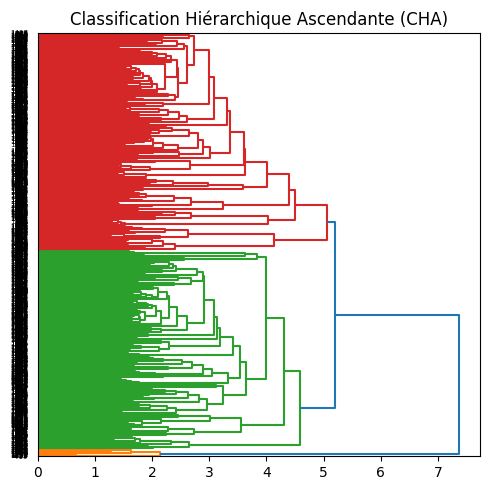

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
dendrogram(Z, orientation='right')
plt.title("Classification Hiérarchique Ascendante (CHA)")
plt.tight_layout()
plt.show()

Clustering

In [16]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=5,  linkage='ward')
labels = cluster.fit_predict(X.values)
df['cluster'] = labels
df = df.reset_index()

Contenu des clusters

In [19]:
df_w = pd.DataFrame(X.values, 
                    columns=vectorizer.get_feature_names_out()) 
df_w[df["cluster"] == 1].max().sort_values(ascending=False).head(5)

llm           0.678216
simulation    0.670769
agents        0.665112
llms          0.653105
agent         0.557816
dtype: float64

## Application : Faire un nuage de mots avec WordCloud

Un coup d'oeil à la [documentation](https://amueller.github.io/word_cloud/)